In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
path = r'E:\E-commerce Analysis\Data\processed\vendas_mensais_tratada.csv'

In [3]:
df = pd.read_csv(path, sep=';')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 25 non-null     int64  
 1   mes                 25 non-null     int64  
 2   quantidade_pedidos  25 non-null     int64  
 3   faturamento         25 non-null     float64
 4   ticket_medio        25 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 1.1 KB


In [5]:
df.head(10)

,ano,mes,quantidade_pedidos,faturamento,ticket_medio
0,2016,9,4,252.239994,84.079998
1,2016,10,324,59090.479999,182.378025
2,2016,12,1,19.620001,19.620001
3,2017,1,800,138488.040064,173.110050
4,2017,2,1780,291908.009507,163.993264
5,2017,3,2682,449863.599528,167.734377
6,2017,4,2404,417788.029499,173.788698
7,2017,5,3700,592918.820136,160.248330
8,2017,6,3245,511276.380329,157.558207
9,2017,7,4026,592382.919487,147.139324


In [6]:
pd.options.display.float_format = '{:,.2f}'.format

In [7]:
df['faturamento'].sum()

np.float64(16008872.120054841)

In [8]:
df.isnull().sum()

ano                   0
mes                   0
quantidade_pedidos    0
faturamento           0
ticket_medio          0
dtype: int64

In [9]:
#Faturamento por Mês
df['faturamento'].groupby([df['ano'], df['mes']]).sum()

ano   mes
2016  9           252.24
      10       59,090.48
      12           19.62
2017  1       138,488.04
      2       291,908.01
      3       449,863.60
      4       417,788.03
      5       592,918.82
      6       511,276.38
      7       592,382.92
      8       674,396.32
      9       727,762.45
      10      779,677.88
      11    1,194,882.80
      12      878,401.48
2018  1     1,115,004.18
      2       992,463.34
      3     1,159,652.12
      4     1,160,785.48
      5     1,153,982.15
      6     1,023,880.50
      7     1,066,540.75
      8     1,022,425.32
      9         4,439.54
      10          589.67
Name: faturamento, dtype: float64

In [10]:
df.describe()

,ano,mes,quantidade_pedidos,faturamento,ticket_medio
count,25.00,25.00,25.00,25.00,25.00
mean,"2,017.28",6.56,"3,977.64","640,354.88",158.05
std,0.68,3.44,"2,699.94","431,679.00",41.39
min,"2,016.00",1.00,1.00,19.62,19.62
25%,"2,017.00",4.00,"1,780.00","291,908.01",154.84
50%,"2,017.00",7.00,"4,285.00","674,396.32",160.82
75%,"2,018.00",9.00,"6,512.00","1,023,880.50",168.36
max,"2,018.00",12.00,"7,544.00","1,194,882.80",277.47


In [11]:
faturamento_mes = df['faturamento'].groupby([df['mes']]).sum()
faturamento_ano = df['faturamento'].groupby([df['ano']]).sum()

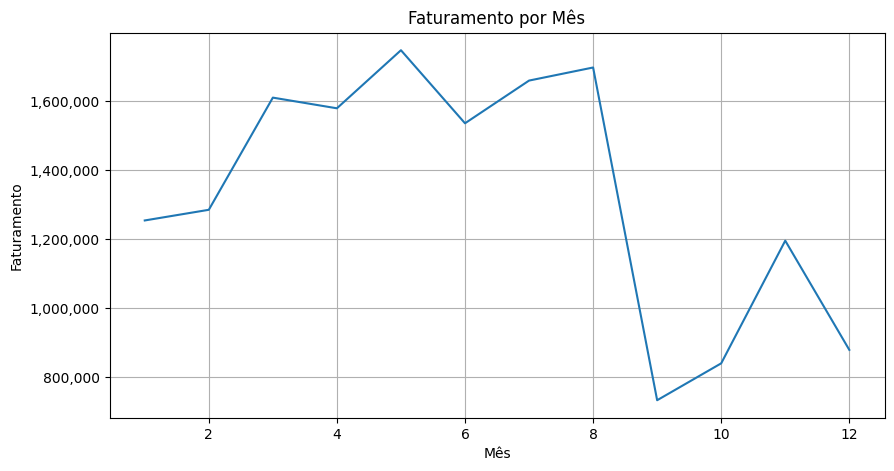

In [12]:
plt.figure(figsize=(10,5))

ax = faturamento_mes.plot()

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Faturamento por Mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.grid()

plt.show()

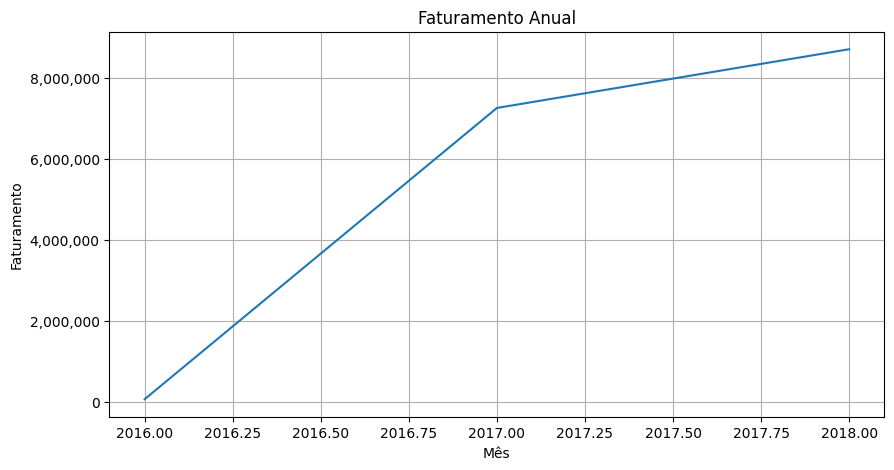

In [13]:
plt.figure(figsize=(10,5))

ax = faturamento_ano.plot()

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Faturamento Anual")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.grid()

plt.show()

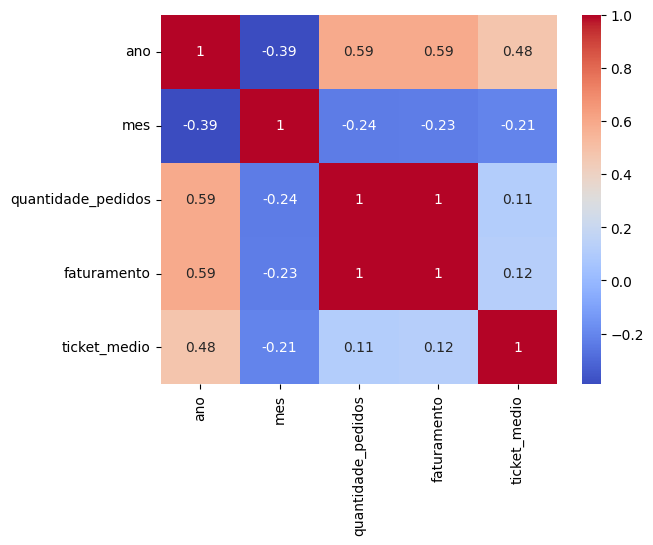

In [14]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()